In [33]:
import torch
import gpytorch
import botorch
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll, ExactMarginalLogLikelihood
from botorch.acquisition import qLogExpectedImprovement
from botorch.optim import optimize_acqf
import matplotlib.pyplot as plt
import pfns4bo
from pfns4bo.scripts.acquisition_functions import TransformerBOMethod
from tqdm import tqdm
from RFF import RFFSampler
from Aquisition_sampling import generate_sobol_points
import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings

In [5]:
rff_sampler = RFFSampler(1000, 1, 1, 1.0, "Matern32")
rff_sampler.omegas = rff_sampler.omegas.reshape(rff_sampler.num_features, rff_sampler.input_dim)

In [6]:
decision_variables = torch.linspace(-5, 5, 10000, dtype=torch.float64).reshape(-1, 1)
print(decision_variables.shape)
function_samples = rff_sampler.sample(decision_variables)

torch.Size([10000, 1])


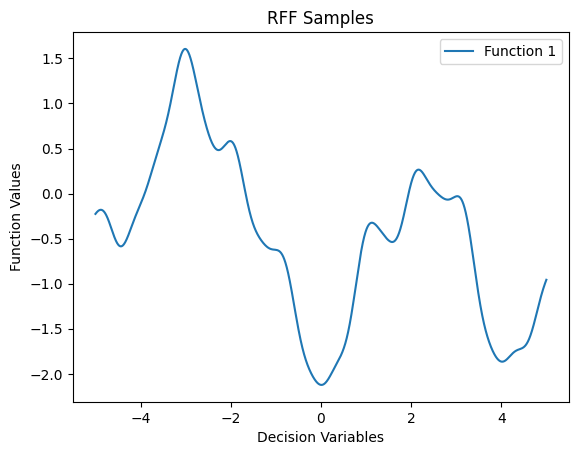

In [7]:
plt.plot(decision_variables.numpy(), function_samples[:, 0].numpy(), label='Function 1')
plt.xlabel('Decision Variables')
plt.ylabel('Function Values')
plt.title('RFF Samples')
plt.legend()
plt.show()

In [23]:
x_train = torch.linspace(0.0, 1.0, 20, dtype=torch.float64).reshape(-1, 1)
y_train = rff_sampler.sample(x_train)

In [ ]:
# Parameters
N_iters = 50
bounds = torch.Tensor([[0.0], [1.0]])
q = 1
n_restarts = 1
n_samples = 100

In [28]:
# Setup PFN
model_path = pfns4bo.hebo_plus_model
pfn = TransformerBOMethod(torch.load(model_path, weights_only=False), device='cuda')

In [31]:
# Generate sampling scheme
x_test = generate_sobol_points(bounds.to(torch.float64), n_samples=1000, seed=42, device='cpu')

In [34]:
# BO loop
for i in tqdm(range(N_iters)):

    # Maximise Acquisition function
    f_best = y_train.max()
    candidate_idx, acq_value = pfn.observe_and_suggest(
        x_train,
        y_train,
        x_test,
        return_actual_ei=True
    )
    next_x = x_test[candidate_idx].unsqueeze(0)

    # Evaluate and add the new point to the training set
    next_y = rff_sampler.sample(next_x)
    x_train = torch.cat([x_train, next_x])
    y_train = torch.cat([y_train, next_y])

100%|██████████| 50/50 [00:01<00:00, 31.39it/s]


In [35]:
# BO loop
for i in tqdm(range(N_iters)):
    # Setup surrogate model
    model = SingleTaskGP(x_train, y_train)

    # Tune Hyperparams to maximise MLL
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll)

    # Maximise Acquisition function
    f_best = y_train.max()
    qEI = qLogExpectedImprovement(model, f_best)
    candidate, acq_value = optimize_acqf(acq_function=qEI, bounds=bounds, q=q, num_restarts=n_restarts, raw_samples=n_samples)
    next_x = candidate.to(dtype=torch.float64).detach()

    # Evaluate and add the new point to the training set
    next_y = rff_sampler.sample(next_x)
    x_train = torch.cat([x_train, next_x])
    y_train = torch.cat([y_train, next_y])

100%|██████████| 50/50 [00:09<00:00,  5.23it/s]
